# CW 02
# Amplitude and Phase Gratings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from ipywidgets import FloatSlider

# Part 1
In this part we will look at the effect of propagating a plane wave through an amplitude grating of varying size, frequency, and transparency. For simplicity the angular spectrum method and all required plotting routines are already provided. You will be responsible for creating the gratings and analyzing the outputs that you see.

## Part 1.1
To begin, complete the amplitude_grating function. This function should return a binary amplitude grating embedded within the larger simulation domain. This means that regions outside our grating should be completely blocked (i.e. field is 0). Within the grating, there should be equal width stripes of "on" and "off" values. Stripes that are off should be completely transmitting, and stripes that are on should be blocking according to the passed transmission parameter. This means that when transmission is 1, the grating will actually function as a square aperture. 

After implementing this function, you should use the provided plotting routine to verify that the aperture has been created as intended. 



In [2]:
# - No modification necessary -

z_max = 0.25
period = 75e-6
aperture_size = 0.5e-3
transmission = 0
phase_shift = np.pi

In [3]:
# - No modification necessary -

# Physical constants
wavelength = 633e-9        # 633 nm (HeNe laser)
k = 2*np.pi / wavelength   # Wavenumber

# Computational grid
L = 10e-3       # 5 mm square domain
N = 1024       # grid resolution

dx = L / N
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

def angular_spectrum_propagate(U0, z):
    """
    Propagate field U0 by distance z using angular spectrum method.
    """
    # Spatial frequency coordinates
    fx = np.fft.fftfreq(N, dx)
    fy = np.fft.fftfreq(N, dx)
    FX, FY = np.meshgrid(fx, fy)
    
    kx = 2*np.pi*FX
    ky = 2*np.pi*FY
    
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)  # complex to allow evanescent
    
    U0_ft = np.fft.fft2(U0)
    
    propagation_factor = np.exp(1j * kz * z)
    
    Uz = np.fft.ifft2(U0_ft * propagation_factor)
    
    return Uz

def prop_and_plot(U0, z_max):
    Nz = 200
    z_vals = np.linspace(0, z_max, Nz)
    
    x_index = N // 2  # central y slice
    xz_intensity = np.zeros((Nz, N))
    
    for i, z in enumerate(z_vals):
        Uz = angular_spectrum_propagate(U0, z)
        xz_intensity[i,:] = np.abs(Uz[x_index,:])**2
        
    plt.figure(figsize=(7,5))
    plt.imshow(xz_intensity, 
               extent=[-L/2, L/2, 0, z_max],
               aspect='auto',
               origin='lower',
               cmap="viridis")
    
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title("x–z Intensity Cross Section")
    plt.colorbar(label="Intensity")
    plt.show()

In [4]:
def amplitude_grating(period, aperture_size, T):
    """
    Binary amplitude grating inside a square aperture.

    period : grating period (meters)
    aperture_size : width of square aperture (meters)
    T : transmission of low-transmission stripes (0 <= T <= 1)

    Returns:
        Complex field array
    """
    
    # Start with zero field everywhere
    field = np.zeros_like(X, dtype=np.complex128)
    
    # Define square aperture mask
    aperture = (np.abs(X) <= aperture_size/2) & (np.abs(Y) <= aperture_size/2)
    
    # Define binary stripe pattern (along x-direction)
    stripes = np.mod(X + period/2, period) < (period/2)
    
    # Inside aperture:
    # Stripes = 1
    # Gaps = T
    field[aperture & stripes] = 1.0
    field[aperture & (~stripes)] = T
    
    return field

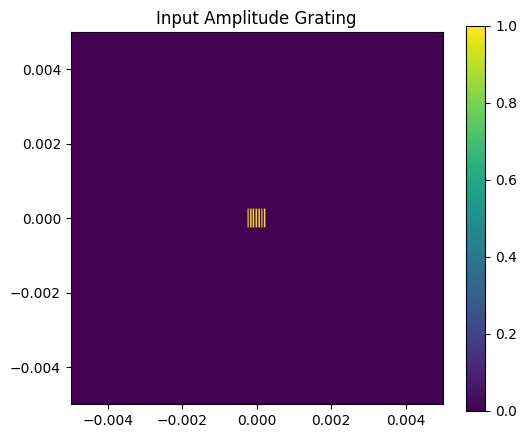

In [5]:
# - No modification necessary -

# Amplitude grating
U0_amp = amplitude_grating(period, aperture_size, T=transmission)
plt.figure(figsize=(6,5))
plt.imshow(np.abs(U0_amp), extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
plt.title("Input Amplitude Grating")
plt.colorbar()
plt.show()


## Part 1.2
Now that you have created the grating, let's investigate how the three parameters affect the output of the system. Experiment with all three in the two provided simulations and discuss the effects that you observe in the section below. Can you tie your observations back to the underlying physics?

In [6]:
# - No modification necessary -

def propagate_amplitude_grating(grating_aperture, grating_period, T):
    U0 = amplitude_grating(grating_period, grating_aperture, T=T)  
    Uz = angular_spectrum_propagate(U0, z_max)
    plt.figure(figsize=(6,5))
    plt.imshow(np.abs(Uz)**2, extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
    plt.title("Intensity at z = %.2f m" % z_max)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.colorbar()
    plt.show()


interact(
    propagate_amplitude_grating, 
    grating_aperture=FloatSlider(min=250e-6, max=750e-6, step=50e-6, readout_format='.6f'), 
    grating_period=FloatSlider(min=25e-6, max=125e-6, step=12.5e-6, readout_format='.6f'),
    T=FloatSlider(min=0, max=1, step=0.1, readout_format='.1f'),
)

interactive(children=(FloatSlider(value=0.00025, description='grating_aperture', max=0.00075, min=0.00025, rea…

<function __main__.propagate_amplitude_grating(grating_aperture, grating_period, T)>

In [7]:
# - No modification necessary -

def prop_and_plot_amp(grating_aperture, grating_period, T):
    Nz = 40
    z_vals = np.linspace(0, z_max, Nz)
    
    U0 = amplitude_grating(grating_period, grating_aperture, T=T)  
    
    x_index = N // 2  # central y slice
    xz_intensity = np.zeros((Nz, N))
    
    for i, z in enumerate(z_vals):
        Uz = angular_spectrum_propagate(U0, z)
        xz_intensity[i,:] = np.abs(Uz[x_index,:])**2
        
    plt.figure(figsize=(7,5))
    plt.imshow(xz_intensity, 
               extent=[-L/2, L/2, 0, 0.1],
               aspect='auto',
               origin='lower',
               cmap="viridis")
    
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title("x–z Intensity Cross Section")
    plt.colorbar(label="Intensity")
    plt.show()

interact(
    prop_and_plot_amp, 
    grating_aperture=FloatSlider(min=250e-6, max=750e-6, step=50e-6, readout_format='.6f'), 
    grating_period=FloatSlider(min=25e-6, max=125e-6, step=12.5e-6, readout_format='.6f'),
    T=FloatSlider(min=0, max=1, step=0.1, readout_format='.1f'),
)

interactive(children=(FloatSlider(value=0.00025, description='grating_aperture', max=0.00075, min=0.00025, rea…

<function __main__.prop_and_plot_amp(grating_aperture, grating_period, T)>

## Discussion
We can think about the input that we have creating as a combination of a global binary grating and a local square aperture. The square aperture creates the classic sinc diffraction pattern, and we observe when changing the size of the aperture that we see that change represented as expected in the sinc function that is created. In a frequency representation, we can think of the binary grating as a DC component with a series of harmonic frequencies above it. This creates an effect where we see copies of the main diffraction pattern at multiple angles, each corresponding to a deflection by the momentum carried in the grating frequency. When we increase the frequency of the binary grating we see these deflection angles grow (corresponding to higher momentum), and when we decrease the frequency we see them shrink. The transmission factor tells us the amplitude of these harmonics, which in turn tells us the strength of the diffracted peaks.

# Part 2
Now that we have looked into how an amplitude grating affects the propagation of light, let's turn to thinking about how modulating phase will work. In this section you should repeat the same logic as before, but this time with a grating that induces a phase change instead of an amplitude change.

## Part 2.1
You will begin by implementing the phase_grating function. This will return a grating in a similar fashion to the amplitude_grating function, but with a few small changes. In the region outside the aperture, instead of setting the amplitude to 0 we will simply say that the phase is set to 0. Within the aperture, "on" stripes will induce a phase change of the passed parameter phi, and stripes that are "off" will have zero phase. The amplitude of the field should be left as 1 everywhere.

After creating the grating you can visualize it with the provided function.

In [8]:
def phase_grating(period, aperture_size, phi):
    """
    Binary phase grating inside a square aperture.

    period : grating period (meters)
    aperture_size : width of square aperture (meters)
    phi : phase shift (0 <= phi <= 2π)

    Returns:
        Complex field array
    """
    
    # Start with uniform phase = 0 everywhere
    field = np.ones_like(X, dtype=np.complex128)
    
    # Define square aperture mask
    aperture = (np.abs(X) <= aperture_size/2) & (np.abs(Y) <= aperture_size/2)
    
    # Binary stripe pattern
    stripes = np.mod(X + period/2, period) < (period/2)
    
    # Inside aperture:
    # stripes → phase phi
    # gaps → phase 0
    field[aperture & stripes] = np.exp(1j * phi)
    field[aperture & (~stripes)] = 1.0
    
    # Outside aperture remains phase 0 (field = 1)
    
    return field

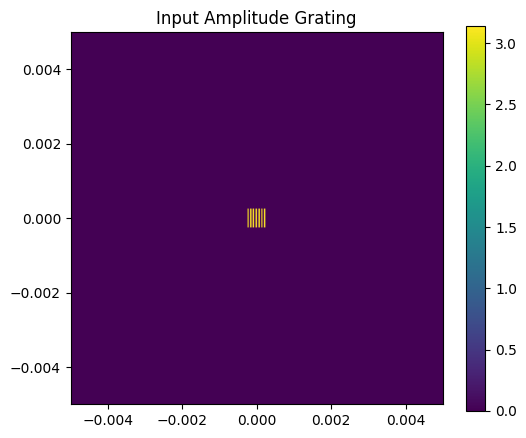

In [9]:
# - No modification necessary -

# Phase grating
U0_phase = phase_grating(period, aperture_size, phi=np.pi)
plt.figure(figsize=(6,5))
plt.imshow(np.angle(U0_phase), extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
plt.title("Input Amplitude Grating")
plt.colorbar()
plt.show()

## Part 2.2
Now as with the amplitude grating, experiment with all three parameters of the grating in the two provided simulations and discuss the effects that you observe in the section below. What key difference do you observe with the 0-order diffracted spot? Why do you think this occurs?

In [10]:
# - No modification necessary -

def propagate_phase_grating(grating_aperture, grating_period, phi):
    U0 = phase_grating(grating_period, grating_aperture, phi=phi)  
    Uz = angular_spectrum_propagate(U0, z_max)
    plt.figure(figsize=(6,5))
    plt.imshow(np.abs(Uz)**2, extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
    plt.title("Intensity at z = %.2f m" % z_max)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.colorbar()
    plt.show()


interact(
    propagate_phase_grating, 
    grating_aperture=FloatSlider(min=250e-6, max=750e-6, step=50e-6, readout_format='.6f'), 
    grating_period=FloatSlider(min=25e-6, max=125e-6, step=12.5e-6, readout_format='.6f'),
    phi=FloatSlider(min=0, max=2*np.pi, step=2*np.pi/32, readout_format='.1f'),
)

interactive(children=(FloatSlider(value=0.00025, description='grating_aperture', max=0.00075, min=0.00025, rea…

<function __main__.propagate_phase_grating(grating_aperture, grating_period, phi)>

In [11]:
# - No modification necessary -

def prop_and_plot_phase(grating_aperture, grating_period, phi):
    Nz = 40
    z_vals = np.linspace(0, z_max, Nz)
    
    U0 = phase_grating(grating_period, grating_aperture, phi=phi)  
    
    x_index = N // 2  # central y slice
    xz_intensity = np.zeros((Nz, N))
    
    for i, z in enumerate(z_vals):
        Uz = angular_spectrum_propagate(U0, z)
        xz_intensity[i,:] = np.abs(Uz[x_index,:])**2
        
    plt.figure(figsize=(7,5))
    plt.imshow(xz_intensity, 
               extent=[-L/2, L/2, 0, 0.1],
               aspect='auto',
               origin='lower',
               cmap="viridis")
    
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title("x–z Intensity Cross Section")
    plt.colorbar(label="Intensity")
    plt.show()

interact(
    prop_and_plot_phase, 
    grating_aperture=FloatSlider(min=250e-6, max=750e-6, step=50e-6, readout_format='.6f'), 
    grating_period=FloatSlider(min=25e-6, max=125e-6, step=12.5e-6, readout_format='.6f'),
    phi=FloatSlider(min=0, max=2*np.pi, step=2*np.pi/32, readout_format='.1f'),
)

interactive(children=(FloatSlider(value=0.00025, description='grating_aperture', max=0.00075, min=0.00025, rea…

<function __main__.prop_and_plot_phase(grating_aperture, grating_period, phi)>

## Discussion
As with the amplitude grating, the size of the grating and the period of it manifest in the shape of the main resulting diffraction pattern and the angle at which the diffraction orders are deflected, respectively. The more interesting change here comes with the role of phi. At a phase of pi, we observe that there is effectively no zero order and the majority of the power has been moved out into the first diffraction orders. At low values of phi, the inverse is true, and we observe that most of the power is transmitted in the central peak and the side peaks are barely visible. This difference mainly comes from the fact that when phi is pi (i.e. e^i*phi = -1), there is no DC component to the frequency of the grating, indicating that none of the light will propagate without deflection.

# Part 3
Use the provided script to visualize the two grating's outputs next to each other. Here we have chosen a "contrast" parameter to let us choose a transmission between 0 and 1 as T=1-contrast and a phase between 0 and pi as phi=pi*contrast. 

When low values of contrast are used, you should observe that the outputs from the amplitude and phase grating are remarkably similar. Thinking about the underlying physics, can you provide an explanation for this?

In [14]:
# - No modification necessary -

def propagate_both_gratings(grating_aperture, grating_period, contrast):
    # Compute amplitude grating propagation
    U0_amp = amplitude_grating(grating_period, grating_aperture, T=1-contrast)  
    Uz_amp = angular_spectrum_propagate(U0_amp, z_max)
    
    # Compute phase grating propagation
    U0_phase = phase_grating(grating_period, grating_aperture, phi=np.pi*contrast)  
    Uz_phase = angular_spectrum_propagate(U0_phase, z_max)
    
    # Create a figure with 1 row, 2 columns
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Amplitude grating plot
    im0 = axs[0].imshow(np.abs(Uz_amp)**2, extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
    axs[0].set_title("[Amplitude Grating] Intensity at z = %.2f m" % z_max)
    axs[0].set_xlabel("x (m)")
    axs[0].set_ylabel("y (m)")
    fig.colorbar(im0, ax=axs[0])
    
    # Phase grating plot
    im1 = axs[1].imshow(np.abs(Uz_phase)**2, extent=[-L/2, L/2, -L/2, L/2], cmap="viridis")
    axs[1].set_title("[Phase Grating] Intensity at z = %.2f m" % z_max)
    axs[1].set_xlabel("x (m)")
    axs[1].set_ylabel("y (m)")
    fig.colorbar(im1, ax=axs[1])
    
    plt.tight_layout()
    plt.show()
    
interact(
    propagate_both_gratings, 
    grating_aperture=FloatSlider(min=250e-6, max=750e-6, step=50e-6, readout_format='.6f'), 
    grating_period=FloatSlider(min=25e-6, max=125e-6, step=12.5e-6, readout_format='.6f'),
    contrast=FloatSlider(min=0, max=1, step=0.05, readout_format='.1f'),
)

interactive(children=(FloatSlider(value=0.00025, description='grating_aperture', max=0.00075, min=0.00025, rea…

<function __main__.propagate_both_gratings(grating_aperture, grating_period, contrast)>

## Discussion
As mentioned in the description of the behavior of the phase grating, when the grating has a phase of pi, there is no DC component to its Fourier transform. When we think about the inverse problem, where the grating has a phase that is approximately 0, we expect that there will be a DC component to the Fourier transform, indicating that the zero-order should exist. This will make the diffraction pattern appear much more similar to that of the amplitude grating.

Another way to think about this problem is to think about where the transmissions of the contrasting stripes of the gradient lie in the complex plane. With zero contrast, for both an amplitude grating and a phase grating, the transmission is simply 1. Adding a minor amount of phase change will slightly rotate the transmission about the origin, but ultimately it will still be approximately 1. Slightly reducing the transmission will likewise minimally modify the location of the transmission value, but still leave it close to 1. In this way we can visualize that the limit of contrast going to 0 is the same for both the amplitude and phase gratings, and therefore their resulting behavior should converge as contrast goes to 0.